# 9강. [실습] 이진화와 모폴로지 연산
**영상정보처리 | 2026년 1학기 | 교수 김하연**

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['image.cmap'] = 'gray'

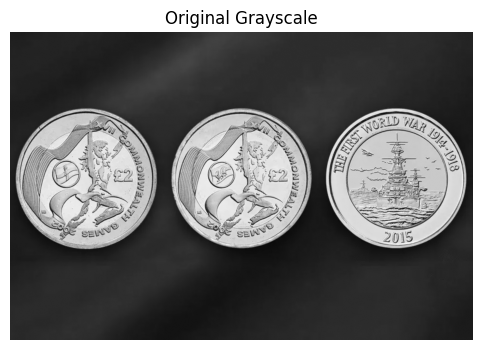

In [2]:
# 실습용 이미지 로드 (본인 이미지 경로로 변경)
img = cv2.imread('coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')
plt.show()

---
## 1. 히스토그램 확인

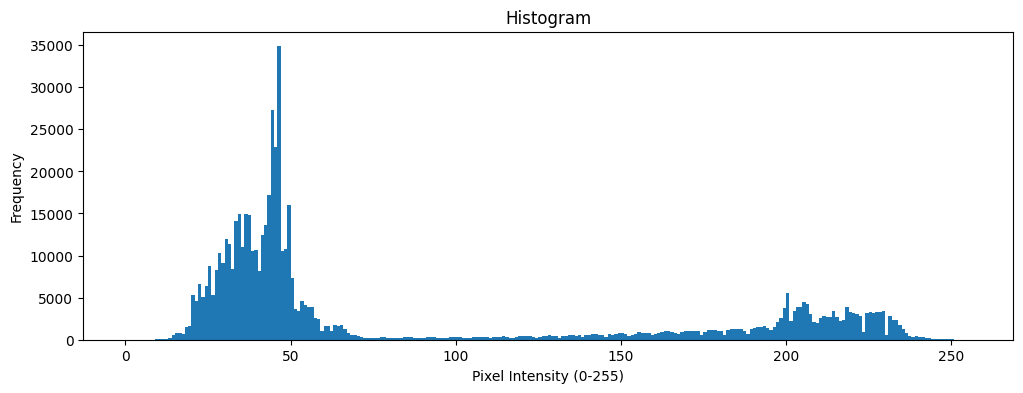

In [3]:
# 히스토그램으로 밝기 분포 확인
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.title('Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.show()

---
## 2. 글로벌 이진화 (수동 임계값)

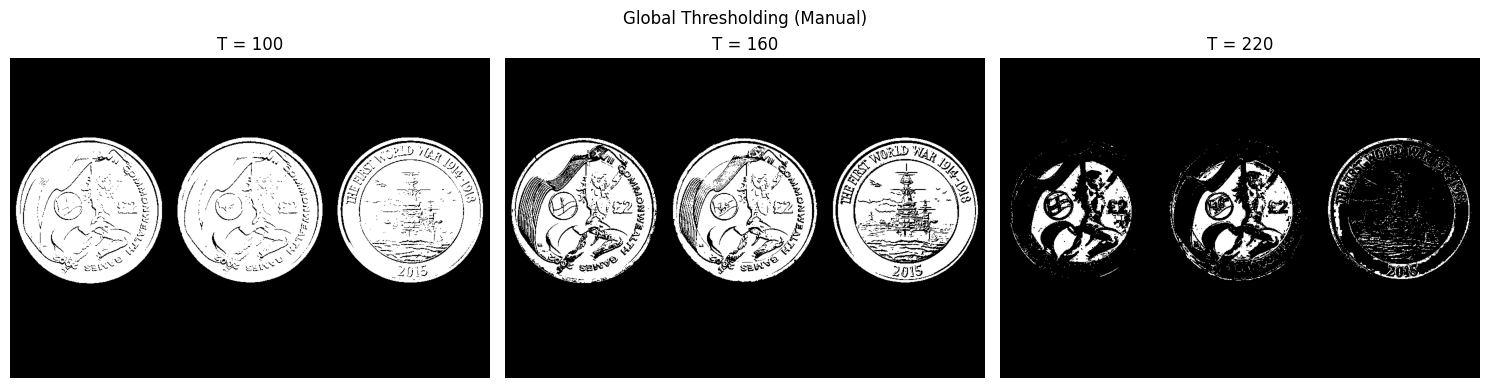

In [4]:
# 임계값을 수동으로 바꿔가며 결과 비교
thresholds = [100, 160, 220]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, thresholds):
    _, binary = cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)
    ax.imshow(binary, cmap='gray')
    ax.set_title(f'T = {t}')
    ax.axis('off')
plt.suptitle('Global Thresholding (Manual)')
plt.tight_layout()
plt.show()

---
## 3. 오츠(Otsu) 이진화

Otsu가 찾은 최적 임계값: 119.0


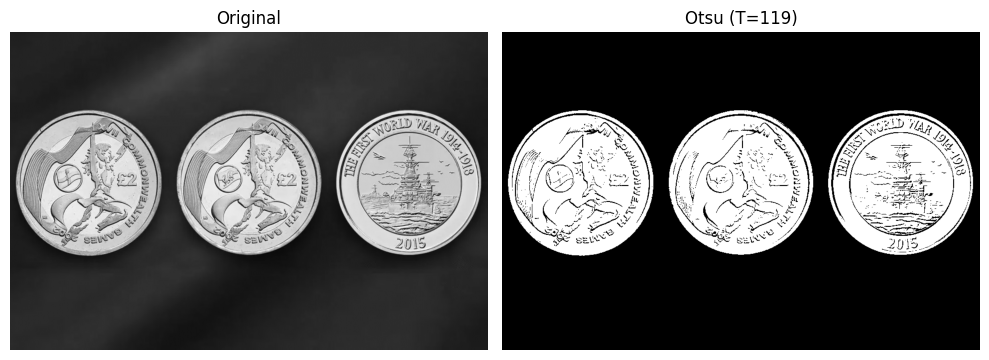

In [5]:
# cv2.THRESH_OTSU 플래그를 추가하면 T를 자동 계산
otsu_t, otsu_binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Otsu가 찾은 최적 임계값: {otsu_t}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(otsu_binary, cmap='gray')
axes[1].set_title(f'Otsu (T={int(otsu_t)})')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

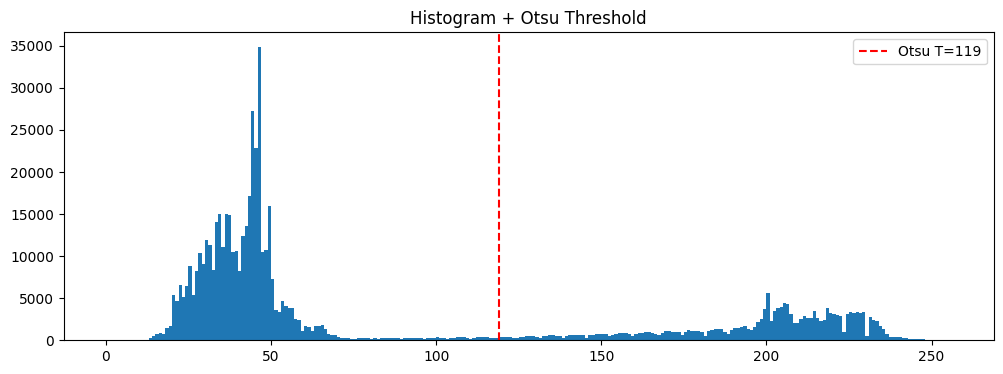

In [6]:
# 히스토그램 위에 오츠 임계값 표시
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.axvline(x=otsu_t, color='r', linestyle='--', label=f'Otsu T={int(otsu_t)}')
plt.legend()
plt.title('Histogram + Otsu Threshold')
plt.show()

---
## 4. 적응형 이진화 (Adaptive Thresholding)

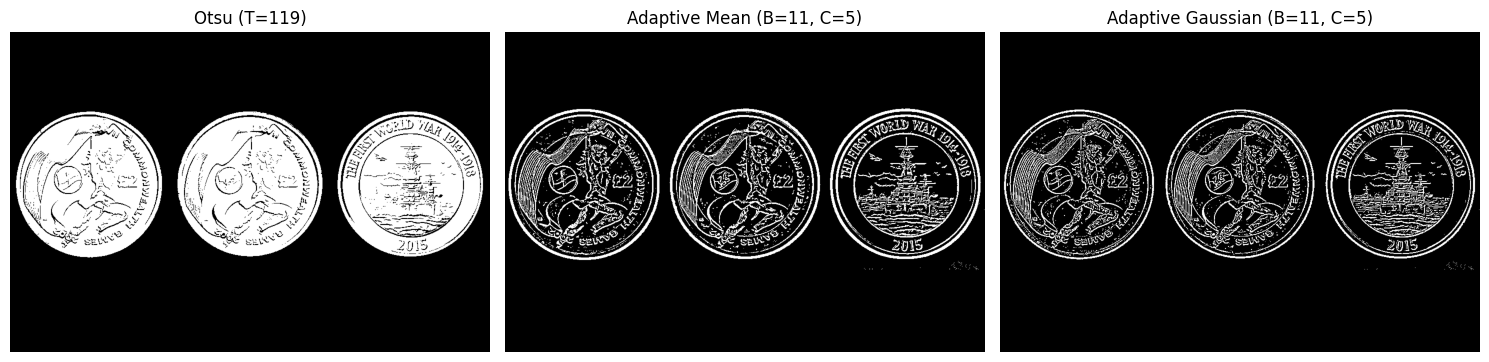

In [7]:
# 균일 조명에서는 적응형 이진화는 오히려 에지처럼 보이는 한계가 있음. 불균일 조명에서 진가를 발휘
# Mean 방식: 블록 내 평균 - C
adapt_mean = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, blockSize=11, C=5
)

adapt_gauss = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize=11, C=5
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(otsu_binary, cmap='gray')
axes[0].set_title(f'Otsu (T={int(otsu_t)})')
axes[1].imshow(adapt_mean, cmap='gray')
axes[1].set_title('Adaptive Mean (B=11, C=5)')
axes[2].imshow(adapt_gauss, cmap='gray')
axes[2].set_title('Adaptive Gaussian (B=11, C=5)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

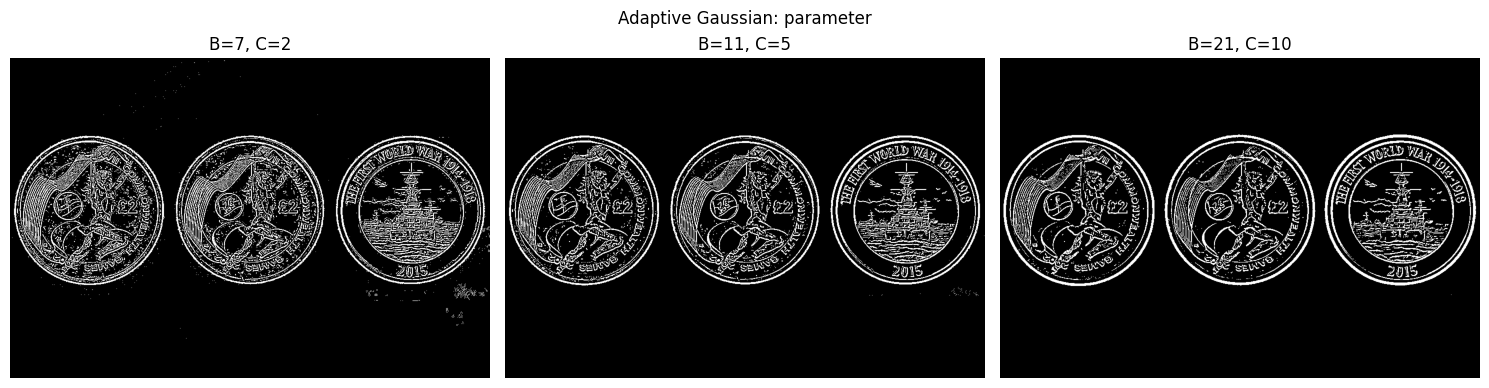

In [8]:
# blockSize와 C를 바꿔가며 결과 비교
params = [(7, 2), (11, 5), (21, 10)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (b, c) in zip(axes, params):
    result = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, b, c
    )
    ax.imshow(result, cmap='gray')
    ax.set_title(f'B={b}, C={c}')
    ax.axis('off')
plt.suptitle('Adaptive Gaussian: parameter')
plt.tight_layout()
plt.show()

---
## 5. 모폴로지 연산: 침식(Erosion)과 팽창(Dilation)

In [9]:
# 구조 요소 생성
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))      # 직사각형
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))    # 십자형
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)) # 타원형

print('Rect 3x3:\n', kernel_rect)
print('\nCross 3x3:\n', kernel_cross)
print('\nEllipse 5x5:\n', kernel_ellipse)

Rect 3x3:
 [[1 1 1]
 [1 1 1]
 [1 1 1]]

Cross 3x3:
 [[0 1 0]
 [1 1 1]
 [0 1 0]]

Ellipse 5x5:
 [[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]


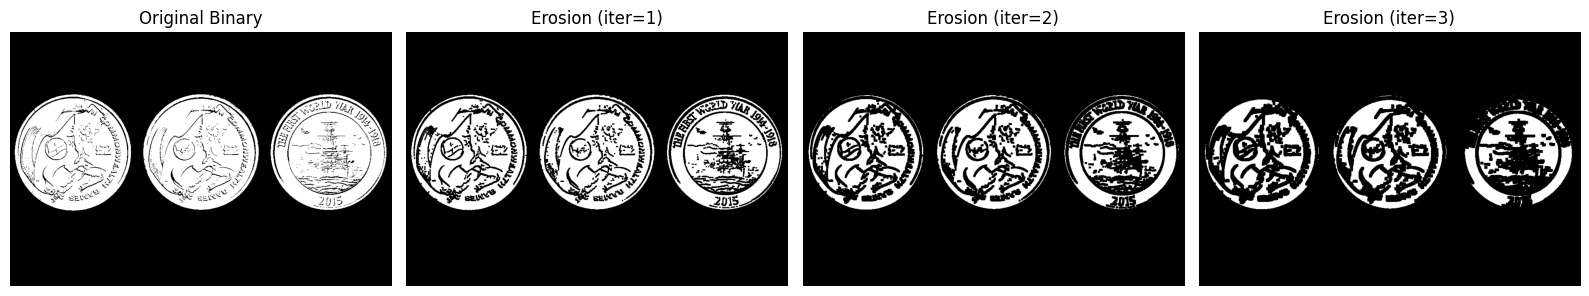

In [10]:
# 침식: 경계를 깎아 노이즈 제거 (반복 횟수에 따른 변화)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(otsu_binary, cmap='gray')
axes[0].set_title('Original Binary')

for i, it in enumerate([1, 2, 3]):
    eroded = cv2.erode(otsu_binary, kernel, iterations=it)
    axes[i+1].imshow(eroded, cmap='gray')
    axes[i+1].set_title(f'Erosion (iter={it})')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

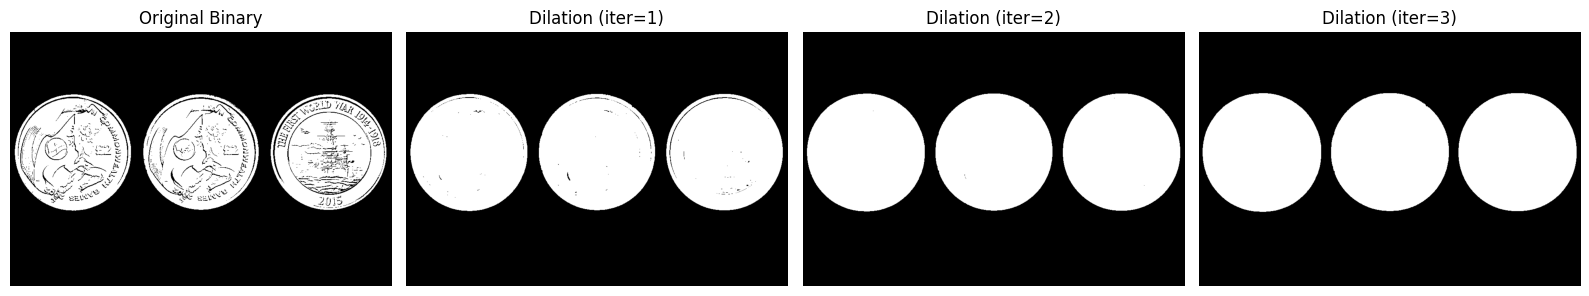

In [11]:
# 팽창: 경계를 불려 구멍 메우기 (반복 횟수에 따른 변화)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(otsu_binary, cmap='gray')
axes[0].set_title('Original Binary')

for i, it in enumerate([1, 2, 3]):
    dilated = cv2.dilate(otsu_binary, kernel, iterations=it)
    axes[i+1].imshow(dilated, cmap='gray')
    axes[i+1].set_title(f'Dilation (iter={it})')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

---
## 6. 열기(Opening)와 닫기(Closing)

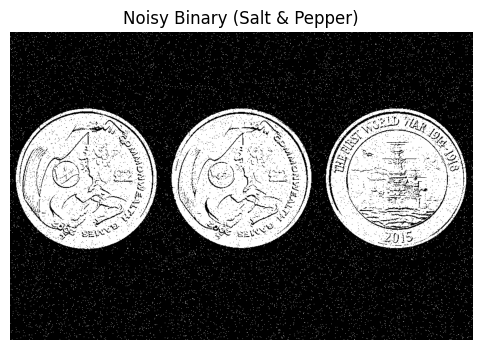

In [12]:
# Salt & Pepper 노이즈 추가 (테스트용)
noisy = otsu_binary.copy()
num_salt = int(0.02 * gray.size)
num_pepper = int(0.02 * gray.size)

# Salt (흰 점)
coords = [np.random.randint(0, i, num_salt) for i in gray.shape]
noisy[coords[0], coords[1]] = 255
# Pepper (검은 점)
coords = [np.random.randint(0, i, num_pepper) for i in gray.shape]
noisy[coords[0], coords[1]] = 0

plt.imshow(noisy, cmap='gray')
plt.title('Noisy Binary (Salt & Pepper)')
plt.axis('off')
plt.show()

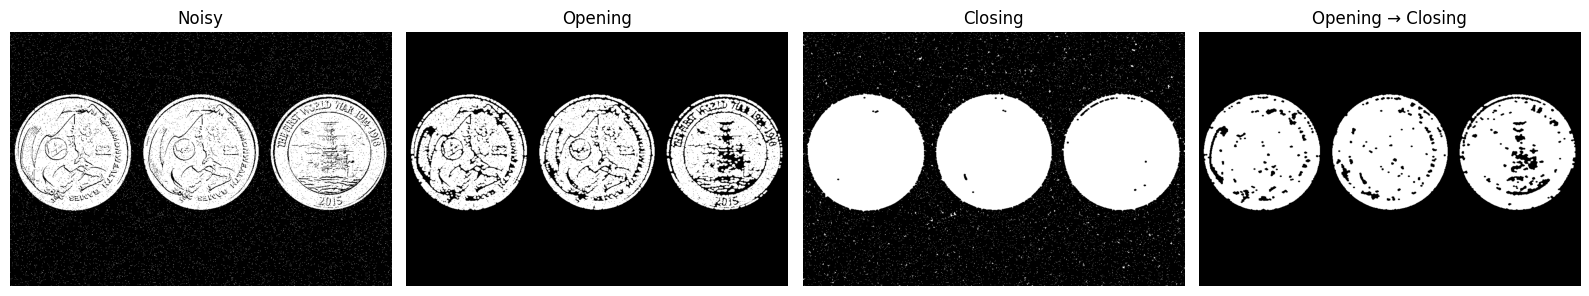

In [13]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Opening = 침식 → 팽창: 외부 노이즈(Salt) 제거
opened = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)

# Closing = 팽창 → 침식: 내부 구멍(Pepper) 제거
closed = cv2.morphologyEx(noisy, cv2.MORPH_CLOSE, kernel)

# Opening → Closing: 둘 다 제거
open_close = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Noisy', 'Opening', 'Closing', 'Opening → Closing']
images = [noisy, opened, closed, open_close]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. 히스토그램 평활화 (Histogram Equalization)

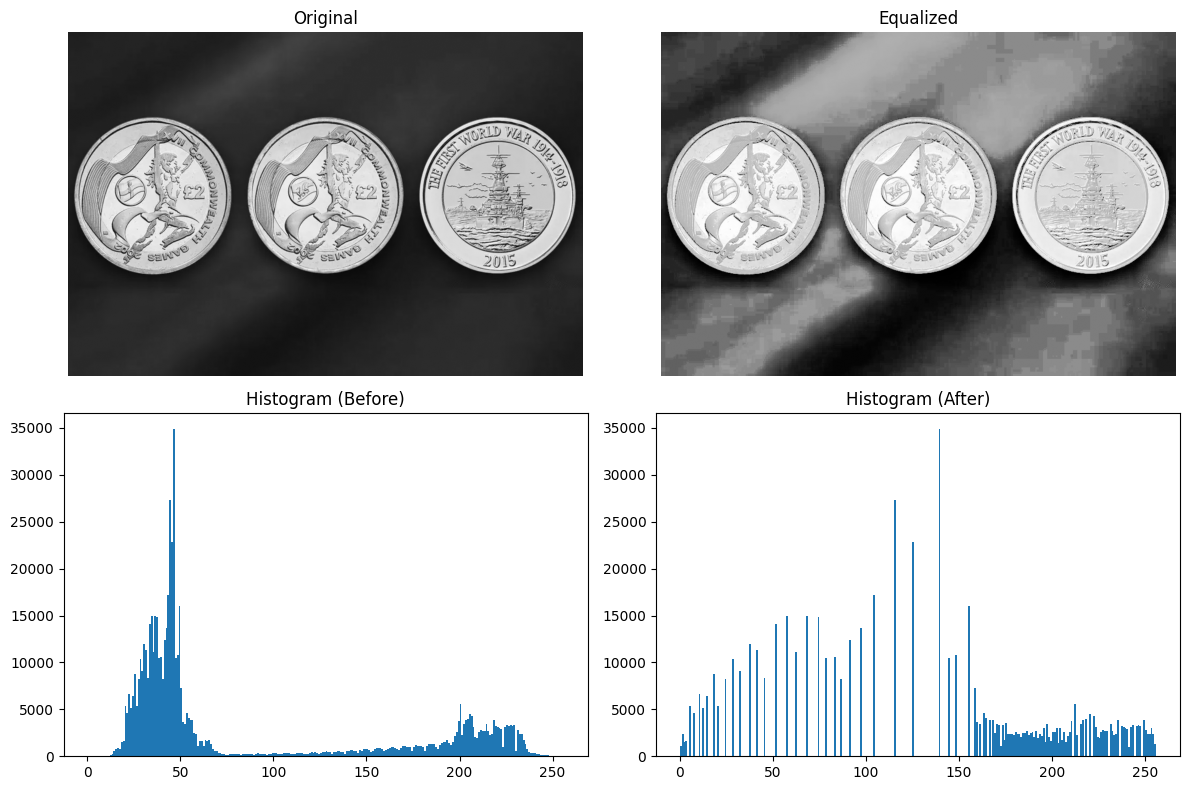

In [14]:
# 히스토그램 평활화: 명암 대비를 자동으로 개선
equalized = cv2.equalizeHist(gray)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(equalized, cmap='gray')
axes[0, 1].set_title('Equalized')
axes[0, 1].axis('off')

axes[1, 0].hist(gray.ravel(), bins=256, range=[0, 256])
axes[1, 0].set_title('Histogram (Before)')

axes[1, 1].hist(equalized.ravel(), bins=256, range=[0, 256])
axes[1, 1].set_title('Histogram (After)')

plt.tight_layout()
plt.show()

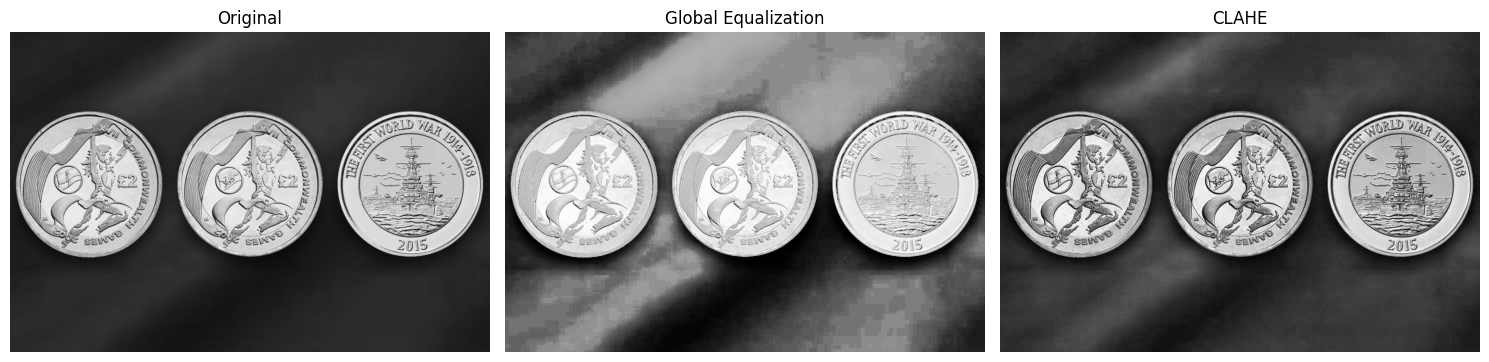

In [15]:
# CLAHE: 적응형 히스토그램 평활화 (로컬 대비 개선)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_result = clahe.apply(gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('Global Equalization')
axes[2].imshow(clahe_result, cmap='gray')
axes[2].set_title('CLAHE')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

---
## 8. 종합 파이프라인: 이진화 → 모폴로지 → 컨투어 추출

검출된 객체 수: 3


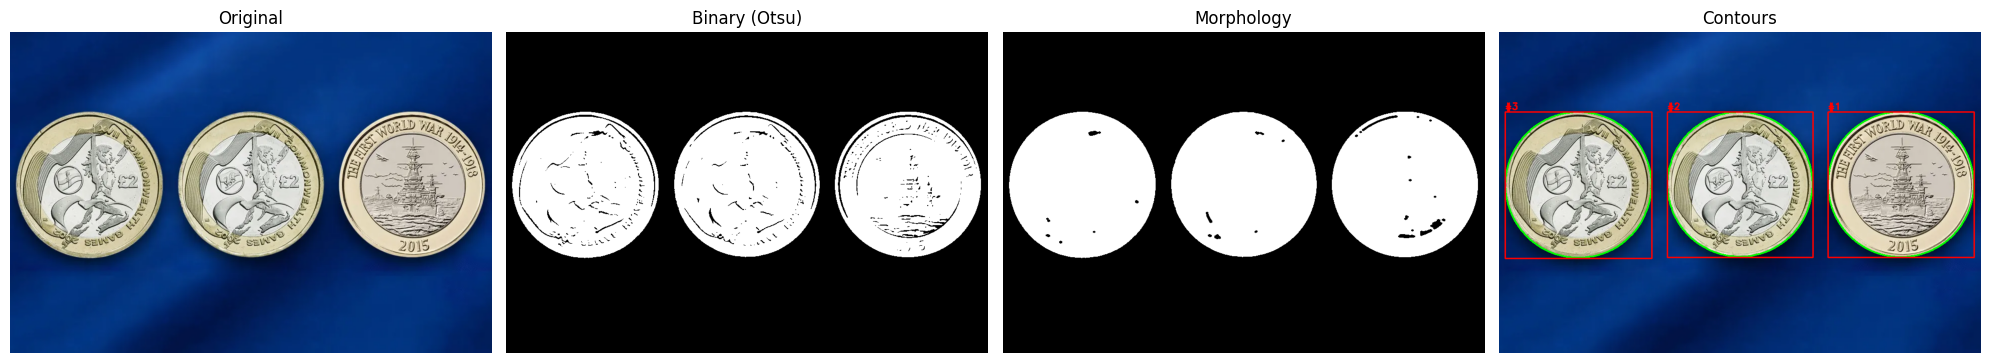

In [16]:
# 전체 파이프라인 실습
# 1) 블러로 노이즈 제거
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 2) 오츠 이진화
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3) 모폴로지 (Opening → Closing)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
morph = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
morph = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, kernel)

# 4) 컨투어 추출
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5) 결과 시각화
result = img.copy()
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if area < 500:  # 너무 작은 컨투어 무시
        continue
    cv2.drawContours(result, [cnt], -1, (0, 255, 0), 2)
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 2)
    cv2.putText(result, f'#{i+1}', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

print(f'검출된 객체 수: {len([c for c in contours if cv2.contourArea(c) >= 500])}')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles = ['Original', 'Binary (Otsu)', 'Morphology', 'Contours']
images = [
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
    binary,
    morph,
    cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()